# We analyze the sensitivity of the design to fabrication errors

Due to fabrication imperfections, the design may not turn out exactly as we expect. We want to understand what impacts these fabrication variations will have. Here we consider two types of fabrication imperfections: 

- etch depth (the partial etch goes too far down) $\sim\mathcal{N}(0,5nm)$
- Ovet/underetched (the teeth are too large or small) $\sim\mathcal{N}(0,5nm)$

In [5]:
import autograd.numpy as npa
import numpy as np 
import matplotlib.pyplot as plt
from autograd import value_and_grad

import tidy3d as td
import tidy3d.web as web
td.config.logging_level = "ERROR"

import pickle

from main import (make_sim, get_coupling_efficiency, projection_builder, apodized_to_widths,
                    R, r0, initial_fill_factor, grating_period,
                    etch_depth, to_substrate, N_teeth, n_wl, wl_range)

# used for Monte Carlo
seed = 42

We will load our previous optimized designs a little lower down. Lets set up a conveniance function here.

In [7]:
# load files later for us
def load_history(filename):
    with open(filename, "r") as f:
        file = pickle.load(f)
    return file

This function takes in the parameters of the grating coupler and returns a fucntion that allows you to purturb them.

In [3]:
def make_variation_builder(params):
    widths = params[:-3]
    r0 = params[-3]
    etch_depth = params[-2]
    to_substrate = params[-1]
    
    def variation_builder(etch_delta=0.000,overetch_delta=0.000):
        return make_sim(widths, 
            r0=r0, 
            etch_depth=etch_depth+etch_delta, 
            to_substrate=to_substrate, 
            dilation=overetch_delta)
    
    return variation_builder

In [4]:
# The parameters have a std of 5nm
sigmas = {
    "etch_depth": 0.005,
    "overetch": 0.005
}

## Compute the Variance of Initial optimization with Monti Carlo

We will first compute the variance of the initial optimization using the Monti Carlo method. We sample from the normal distributions defined above to find the distribution.

In [ ]:
# pull out the parameters from the initial optimization
data = load_history("data/opt/initial.pkl")
param_opt = data['history']['params'][-1]

# make a variation builder fucntion
variation_builder = make_variation_builder(param_opt)

# set up the random seed and number of samples
seed = 42
num_samples = 20

# define standard deviation of the fabrication imperfections
sigma_vector = np.array([
    sigmas["etch_depth"],
    sigmas["overetch"]
])

# sample from the normal distributions
rng = np.random.default_rng(seed)
samples = rng.standard_normal(size=(num_samples, len(sigma_vector))) * sigma_vector

# make a dictionary of the samples
batch_sims = {"nominal": variation_builder()}
batch_sims.update(
    {f"sample_{idx+1}": variation_builder(*tuple(sample)) for idx, sample in enumerate(samples)}
)

FileNotFoundError: [Errno 2] No such file or directory: 'data/opt/initial.pkl'

In [ ]:
# define the batch
batch = web.Batch(simulations=batch_sims,verbose=True)

# run the batch
batch_data = batch.run(path_dir="data/tidy3d_output")

Now we plot the distribution across the bandwidth and the average coupling efficency

In [ ]:
# pull out the names of the simulations
ordered_names = list(batch_data.keys())
coupling_efficiencies = []
average_coupling_efficiency = []

# grab the coupling efficiencies and average them
for name in ordered_names:
    sim_data = batch_data[name]
    coupling_efficiencies.append(get_coupling_efficiency(sim_data))
    average_coupling_efficiency.append(np.mean(coupling_efficiencies[-1]))

# make everything a nice to work with 
coupling_efficiencies = np.vstack(coupling_efficiencies)
average_coupling_efficiency = np.array(average_coupling_efficiency)
nominal_index = ordered_names.index("nominal")
nominal_coupling_efficiency = coupling_efficiencies[nominal_index]

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(10,4))

# plot the coupling efficiencies 
for name, spectrum in zip(ordered_names, coupling_efficiencies):
    if name == "nominal":
        continue
    ax[0].plot(wl_range, spectrum, color="lightgray", alpha=0.6, linewidth=0.5, zorder=0)

# plot the nominal coupling efficiency
ax[0].plot(wl_range, nominal_coupling_efficiency, color="black", linewidth=2, label="nominal")

# plot the mean and 90% confidence interval
mean_spectrum = np.mean(coupling_efficiencies, axis=0)
precentile90 = np.percentile(coupling_efficiencies, 90, axis=0)
precentile10 = np.percentile(coupling_efficiencies, 10, axis=0)
ax[0].fill_between(wl_range, precentile10, precentile90, color="tab:blue", alpha=0.3, zorder=0, label="90% confidence interval")
ax[0].plot(wl_range, mean_spectrum, color="orange", linewidth=2, linestyle="--", label="mean")


ax[0].set_xlabel("Wavelength (um)")
ax[0].set_ylabel("Coupling Efficiency")
ax[0].grid(True, linestyle="--", alpha=0.5)
ax[0].set_xlim(wl_range[0], wl_range[-1])
ax[0].legend()
ax[0].set_title("Coupling Efficiency Spectra")

# plot the histogram of the average coupling efficiency
ax[1].hist(average_coupling_efficiency,bins="auto",color="tab:blue",alpha=0.7,label="samples")
ax[1].axvline(average_coupling_efficiency[0],color="black",linewidth=2,label="nominal")
ax[1].set_xlabel("Coupling Efficiency")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Monti Carlo")
ax[1].grid(True, linestyle="--", alpha=0.5)
ax[1].legend()
ax[1].set_title("Average Coupling Efficiency")

plt.tight_layout()
plt.show()

# 50nm example: Monti carlo vs adjoint

In [5]:
history50 = load_history("data/stochastic_opt_50nm.json")
project50, inverse_project50 = projection_builder()

variation_builder50 = make_variation_builder(history50["params"][-1])

seed = 42
num_samples = 100

sigma_vector = np.array([
    sigmas["etch_depth"],
    sigmas["alignment"],
    sigmas["overetch"]
])
rng = np.random.default_rng(seed)
samples = rng.standard_normal(size=(num_samples, len(sigma_vector))) * sigma_vector

In [6]:
sims = {"nominal": variation_builder50()}
sims.update(
    {f"sample_{idx+1}": variation_builder50(*tuple(sample)) for idx, sample in enumerate(samples)}
)

20:08:31 EDT WARNING: Starting in version 2.11, the behavior of GaussianBeam    
             with direction '-' and non-zero 'waist_distance' has changed. The  
             waist position is now defined consistently for both forward- and   
             backward-propagating beams: a positive 'waist_distance' always     
             places the beam waist behind the source/monitor plane (toward the  
             negative normal axis). This ensures reciprocity between Gaussian   
             sources and overlap monitors used for port-based S-matrix          
             calculations. If your simulation relied on the previous behavior   
             (where the waist position flipped with direction), you may need to 
             adjust your waist distance values.                                 

In [7]:
batch_data = web.run_async(sims, folder_name="dominic", verbose=True)

Output()

20:09:24 EDT Started working on Batch containing 101 tasks.

20:11:16 EDT Maximum FlexCredit cost: 2.525 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after    
             completion.

Output()

20:11:41 EDT Batch complete.

In [8]:
ordered_names = list(sims.keys())
spectra = []

for name in ordered_names:
    sim_data = batch_data[name]
    spectra.append(get_coupling_efficiency(sim_data))

spectra = np.vstack(spectra)
nominal_index = ordered_names.index("nominal")
nominal_spectrum = spectra[nominal_index]

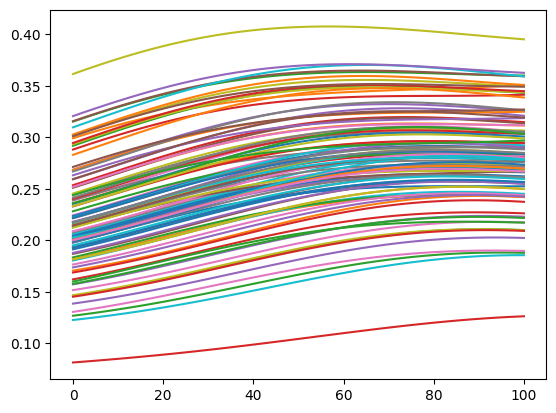

In [10]:
plt.plot(spectra.T)

## Adjoint for 50nm 

In [10]:
params_nominal = project50(history50["params"][-1])
widths = params_nominal[:N_teeth*2+2]
r0 = params_nominal[N_teeth*2+2]
etch_depth = params_nominal[N_teeth*2+3]
to_substrate = params_nominal[N_teeth*2+4]

def objective(params):
    sim = make_sim(widths, 
            r0=r0+params[1], 
            etch_depth=etch_depth+params[0], 
            to_substrate=to_substrate,
            dilation=params[2],
            min_steps_per_wvl=30)
    sim_data = web.run(sim, task_name="GC4um_2D_adjoint_sensitivity", folder_name="dominic", verbose=False)
    return get_coupling_efficiency(sim_data)[n_wl//2]

In [11]:
params0 = np.zeros(3)
value, grad = value_and_grad(objective)(params0)

In [12]:
sigma_vector = np.array([
    sigmas["etch_depth"],
    sigmas["alignment"],
    sigmas["overetch"],
])

scaled = (np.array(grad)) * sigma_vector
variance = scaled @ scaled
std = np.sqrt(variance)

#90th precentile confidence interval
z = 1.28155
p10 = value + z * std
p90 = value - z * std

#set up normalized variance dic
normalized_variance = {
    "etch_depth": scaled[0]**2/ variance, 
    "alignment": scaled[1]**2/ variance,
    "overetch": scaled[2]**2/ variance,
}

(0.0, 1.0)

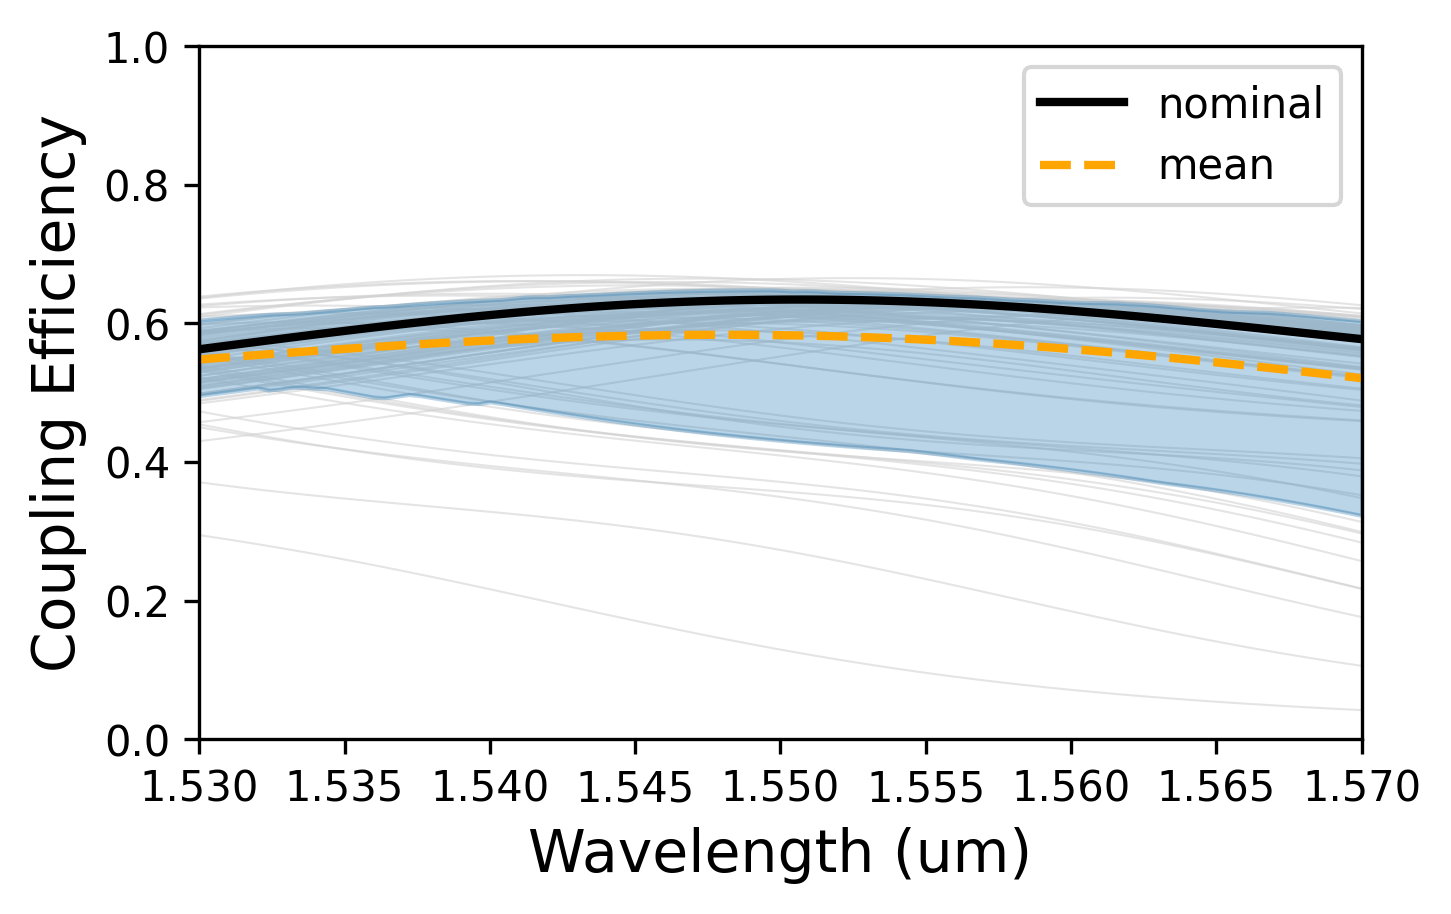

In [29]:
fig,ax = plt.subplots(1,1,figsize=(5,3),dpi=300)

for name, spectrum in zip(ordered_names, spectra):
    if name == "nominal":
        continue
    ax.plot(wl_range, spectrum, color="lightgray", alpha=0.6, linewidth=0.5, zorder=0)

ax.plot(wl_range, nominal_spectrum, color="black", linewidth=2, label="nominal")

mean_spectrum = np.mean(spectra, axis=0)
precentile90 = np.percentile(spectra, 90, axis=0)
precentile10 = np.percentile(spectra, 10, axis=0)
ax.fill_between(wl_range, precentile10, precentile90, color="tab:blue", alpha=0.3, zorder=0)
#ax.fill_between(wl_range, precentile1050, precentile9050, color="tab:orange", alpha=0.3, zorder=0)
ax.plot(wl_range, mean_spectrum, color="orange", linewidth=2, linestyle="--", label="mean")


ax.set_xlabel("Wavelength (um)",fontsize=14)
ax.set_ylabel("Coupling Efficiency",fontsize=14)

ax.set_xlim(wl_range[0], wl_range[-1])
ax.legend()
ax.set_ylim(0,1)



# xs = np.linspace(0,1,100)
# ys = np.exp(-(1/2)*((xs-value)/std)**2)*20

# ax[1].hist(spectra[1:,n_wl//2],bins="auto",color="tab:blue",alpha=0.7,label="samples")
# ax[1].axvline(spectra[0,n_wl//2],color="black",linewidth=2,label="nominal")
# ax[1].plot(xs,ys,color="red",linewidth=2,label="Approximation")
# ax[1].set_xlabel("Coupling Efficiency")
# ax[1].set_ylabel("Frequency")
# ax[1].set_title("Monti Carlo")
# ax[1].grid(True, linestyle="--", alpha=0.5)
# ax[1].legend()

# ax[1].set_title("Coupling Efficiency at 1.55 um")


# ax[2].bar(normalized_variance.keys(), normalized_variance.values())
# ax[2].set_ylabel("Normalized Variance contribution")
# ax[2].set_xlabel("Parameter")
# ax[2].set_title("Normalized Variance of Parameters")
# ax[2].set_yscale("log")

# plt.suptitle("Stochastic Optimization, 50nm mimimum, all std=5nm",fontsize=20)
# plt.tight_layout()
# plt.show()

## Adjoint sesitiity for 100 nm minimum

In [8]:
history100 = load_history("data/stochastic_opt_100nm.json")
project100, inverse_project100 = projection_builder()

variation_builder100 = make_variation_builder(history100["params"][-1])

seed = 42
num_samples = 100

sigma_vector = np.array([
    sigmas["etch_depth"],
    sigmas["alignment"],
    sigmas["overetch"]
])
rng = np.random.default_rng(seed)
samples = rng.standard_normal(size=(num_samples, len(sigma_vector))) * sigma_vector

In [10]:
sims = {"nominal": variation_builder100()}
sims.update(
    {f"sample_{idx+1}": variation_builder100(*tuple(sample)) for idx, sample in enumerate(samples)}
)

In [13]:
batch_data = web.run_async(sims, path_dir="data/tidy3d_output", folder_name="dominic", verbose=True)

Output()

13:28:26 EDT Started working on Batch containing 101 tasks.

13:29:58 EDT Maximum FlexCredit cost: 2.525 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after the
             Batch has completed.

Output()

13:31:27 EDT Batch complete.

Output()

In [14]:
ordered_names = list(sims.keys())
spectra = []

for name in ordered_names:
    sim_data = batch_data[name]
    spectra.append(get_coupling_efficiency(sim_data))

spectra = np.vstack(spectra)
nominal_index = ordered_names.index("nominal")
nominal_spectrum = spectra[nominal_index]

In [15]:
params_nominal = history100["params"][-1]
widths = params_nominal[:N_teeth*2+2]
r0 = params_nominal[N_teeth*2+2]
etch_depth = params_nominal[N_teeth*2+3]
to_substrate = params_nominal[N_teeth*2+4]

def objective(params):
    sim = make_sim(widths, 
            r0=r0+params[1], 
            etch_depth=etch_depth+params[0], 
            to_substrate=to_substrate,
            dilation=params[2],
            min_steps_per_wvl=30)
    sim_data = web.run(sim, task_name="GC4um_2D_adjoint_sensitivity", folder_name="dominic", verbose=False)
    return get_coupling_efficiency(sim_data)[n_wl//2]

In [16]:
params0 = np.zeros(3)
value, grad = value_and_grad(objective)(params0)

In [17]:
sigma_vector = np.array([
    sigmas["etch_depth"],
    sigmas["alignment"],
    sigmas["overetch"],
])

scaled = (np.array(grad)) * sigma_vector
variance = scaled @ scaled
std = np.sqrt(variance)

#90th precentile confidence interval
z = 1.28155
p10 = value + z * std
p90 = value - z * std

#set up normalized variance dic
normalized_variance = {
    "etch_depth": scaled[0]**2/ variance, 
    "alignment": scaled[1]**2/ variance,
    "overetch": scaled[2]**2/ variance,
}

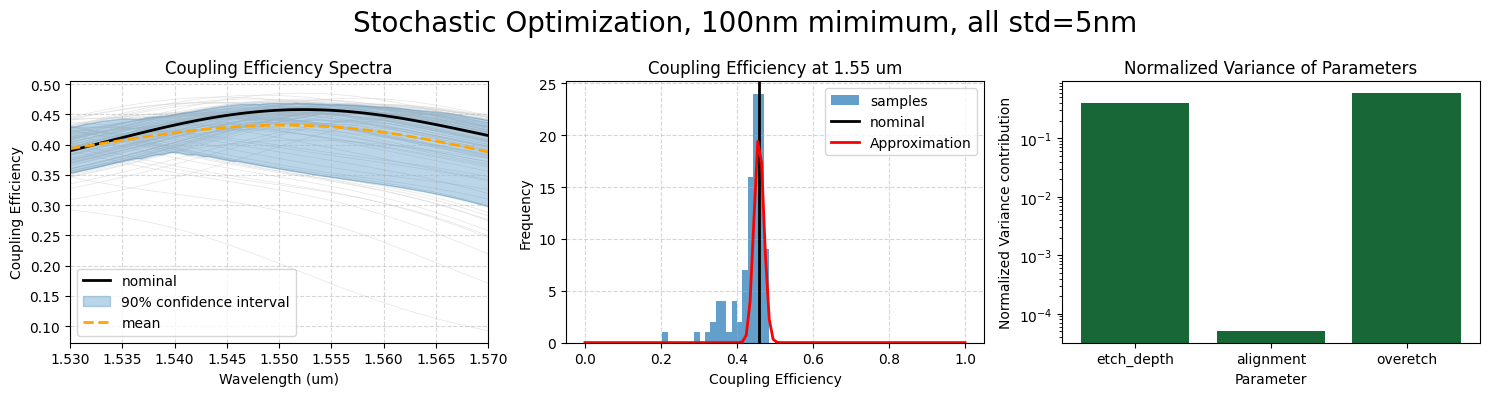

In [19]:
fig,ax = plt.subplots(1,3,figsize=(15,4))

for name, spectrum in zip(ordered_names, spectra):
    if name == "nominal":
        continue
    ax[0].plot(wl_range, spectrum, color="lightgray", alpha=0.6, linewidth=0.5, zorder=0)

ax[0].plot(wl_range, nominal_spectrum, color="black", linewidth=2, label="nominal")

mean_spectrum = np.mean(spectra, axis=0)
precentile90 = np.percentile(spectra, 90, axis=0)
precentile10 = np.percentile(spectra, 10, axis=0)
ax[0].fill_between(wl_range, precentile10, precentile90, color="tab:blue", alpha=0.3, zorder=0, label="90% confidence interval")
ax[0].plot(wl_range, mean_spectrum, color="orange", linewidth=2, linestyle="--", label="mean")


ax[0].set_xlabel("Wavelength (um)")
ax[0].set_ylabel("Coupling Efficiency")
ax[0].grid(True, linestyle="--", alpha=0.5)
ax[0].set_xlim(wl_range[0], wl_range[-1])
ax[0].legend()
ax[0].set_title("Coupling Efficiency Spectra")


xs = np.linspace(0,1,100)
ys = np.exp(-(1/2)*((xs-value)/std)**2)*20

ax[1].hist(spectra[1:,n_wl//2],bins="auto",color="tab:blue",alpha=0.7,label="samples")
ax[1].axvline(spectra[0,n_wl//2],color="black",linewidth=2,label="nominal")
ax[1].plot(xs,ys,color="red",linewidth=2,label="Approximation")
ax[1].set_xlabel("Coupling Efficiency")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Monti Carlo")
ax[1].grid(True, linestyle="--", alpha=0.5)
ax[1].legend()

ax[1].set_title("Coupling Efficiency at 1.55 um")


ax[2].bar(normalized_variance.keys(), normalized_variance.values())
ax[2].set_ylabel("Normalized Variance contribution")
ax[2].set_xlabel("Parameter")
ax[2].set_title("Normalized Variance of Parameters")
ax[2].set_yscale("log")

plt.suptitle("Stochastic Optimization, 100nm mimimum, all std=5nm",fontsize=20)
plt.tight_layout()
plt.show()